# Workbench Setup

In [1]:
import sys, os, collections
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt; plt.rcdefaults()
from matplotlib.pyplot import figure
from collections import Counter

In [2]:
# First we load the TF program
from tf.fabric import Fabric
from tf.app import use

In [3]:
pd.set_option('display.max_rows', None)

In [4]:
%%time
# Now we load a few databases
#BHSaLatest = use('etcbc/bhsa:latest')
#BHSaC = use('etcbc/bhsa', version='c', mod='CenterBLC/BHSaddons/tf')
#BHSa2017 = use('etcbc/bhsa', version='2017', mod='CenterBLC/BHSaddons/tf')

BHS = use('etcbc/bhsa', version="2021", mod='CenterBLC/BHSaddons/tf', hoist=globals())
bhsF, bhsL, bhsT, bhsS = BHS.api.F, BHS.api.L, BHS.api.T, BHS.api.S

LXX = use("CenterBLC/LXX", version="1935", hoist=globals())
lxxF, lxxL, lxxT, lxxS = LXX.api.F, LXX.api.L, LXX.api.T, LXX.api.S

DSS = use('etcbc/dss', hoist=globals())
dssF, dssL, dssT, dssS = DSS.api.F, DSS.api.L, DSS.api.T, DSS.api.S

GNT = use ("CenterBLC/N1904", version="1.0.0", mod="CenterBLC/N1904/BOLcomplement/tf/", hoist=globals())
gntF, gntL, gntT, gntS = GNT.api.F, GNT.api.L, GNT.api.T, GNT.api.S

**Locating corpus resources ...**

Name,# of nodes,# slots / node,% coverage
book,39,10938.21,100
chapter,929,459.19,100
lex,9230,46.22,100
verse,23213,18.38,100
half_verse,45179,9.44,100
sentence,63717,6.70,100
sentence_atom,64514,6.61,100
clause,88131,4.84,100
clause_atom,90704,4.70,100
phrase,253203,1.68,100


**Locating corpus resources ...**

Name,# of nodes,# slots / node,% coverage
book,57,10941.98,100
chapter,1192,523.23,100
verse,30371,20.54,100
subverse,30419,20.50,100
word,623693,1.00,100


**Locating corpus resources ...**

...

**Locating corpus resources ...**

Name,# of nodes,# slots / node,% coverage
book,27,5102.93,100
chapter,260,529.92,100
verse,7944,17.34,100
sentence,8011,17.20,100
group,8945,7.01,46
clause,42506,8.36,258
wg,106868,6.88,533
phrase,69007,1.90,95
subphrase,116178,1.60,135
word,137779,1.00,100


Display is setup for viewtype [syntax-view](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/syntax-view.md#start)

See [here](https://github.com/saulocantanhede/tfgreek2/blob/main/docs/viewtypes.md#start) for more information on viewtypes

CPU times: user 18.1 s, sys: 3.12 s, total: 21.2 s
Wall time: 21.9 s


# Basic (and general) Valence Analysis Process

## Looking for the specific case (`SM<[` as an example)

In [5]:
ValenceOfBwithCMA='''
clause
   phrase function=Pred
      word lex=CM<[
   phrase typ=PP
      w1:word lex=B
      w2:word lex=QWL/

w1 <: w2
'''
ValenceOfBwithCMA = BHS.search(ValenceOfBwithCMA)
BHS.show(ValenceOfBwithCMA, start=1, end=1, extraFeatures={'function', 'lex', 'sp', 'typ', 'ls'}, condensed=True)

  1.25s 99 results


## Extending the Search to retrieve all potential Valence Patterns

In [6]:
ValenceOfCMA='''
clause
   phrase function=Pred
      word lex=NG<[
   phrase typ=PP
      w1:word lex sp=prep
      w2:word lex

w1 <: w2
'''
ValenceOfCMA = BHS.search(ValenceOfCMA)
BHS.table(ValenceOfCMA, start=1, end=5, extraFeatures={'function', 'lex', 'sp', 'typ', 'ls'}, condensed=True)

  1.81s 91 results


## Importing TF Search Result as DF

In [ ]:
BHS.export(ValenceOfCMA, toDir='~/Desktop/course_TF-Workshop/data_export', toFile='ValenceOfCMA.tsv')

In [ ]:
ValenceOfCMA=pd.read_csv('~/Desktop/course_TF-Workshop/data_export/ValenceOfCMA.tsv', delimiter='\t', encoding='utf-16')
pd.set_option('display.max_columns', 50)
ValenceOfCMA.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,NODE2,TYPE2,TEXT2,function2,NODE3,TYPE3,TEXT3,lex3,NODE4,TYPE4,TEXT4,typ4,NODE5,TYPE5,TEXT5,lex5,sp5,NODE6,TYPE6,TEXT6,lex6
0,1,Genesis,12,17,428575,clause,וַיְנַגַּ֨ע יְהוָ֧ה׀ אֶת־פַּרְעֹ֛ה נְגָעִ֥ים ג...,654746,phrase,יְנַגַּ֨ע,Pred,5801,word,יְנַגַּ֨ע,NG<[,654748,phrase,אֶת־פַּרְעֹ֛ה וְאֶת־בֵּיתֹ֑ו,PP,5803,word,אֶת־,>T,prep,5804,word,פַּרְעֹ֛ה,PR<H/
1,2,Genesis,12,17,428575,clause,וַיְנַגַּ֨ע יְהוָ֧ה׀ אֶת־פַּרְעֹ֛ה נְגָעִ֥ים ג...,654746,phrase,יְנַגַּ֨ע,Pred,5801,word,יְנַגַּ֨ע,NG<[,654748,phrase,אֶת־פַּרְעֹ֛ה וְאֶת־בֵּיתֹ֑ו,PP,5808,word,אֶת־,>T,prep,5809,word,בֵּיתֹ֑ו,BJT/
2,3,Genesis,12,17,428575,clause,וַיְנַגַּ֨ע יְהוָ֧ה׀ אֶת־פַּרְעֹ֛ה נְגָעִ֥ים ג...,654746,phrase,יְנַגַּ֨ע,Pred,5801,word,יְנַגַּ֨ע,NG<[,654750,phrase,עַל־דְּבַ֥ר שָׂרַ֖י אֵ֥שֶׁת אַבְרָֽם׃,PP,5810,word,עַל־,<L,prep,5811,word,דְּבַ֥ר,DBR/
3,4,Genesis,32,26,431192,clause,וַיִּגַּ֖ע בְּכַף־יְרֵכֹ֑ו,662601,phrase,יִּגַּ֖ע,Pred,17944,word,יִּגַּ֖ע,NG<[,662602,phrase,בְּכַף־יְרֵכֹ֑ו,PP,17945,word,בְּ,B,prep,17946,word,כַף־,KP/
4,5,Genesis,32,33,431224,clause,כִּ֤י נָגַע֙ בְּכַף־יֶ֣רֶךְ יַעֲקֹ֔ב בְּגִ֖יד ...,662691,phrase,נָגַע֙,Pred,18068,word,נָגַע֙,NG<[,662692,phrase,בְּכַף־יֶ֣רֶךְ יַעֲקֹ֔ב בְּגִ֖יד הַנָּשֶֽׁה׃,PP,18069,word,בְּ,B,prep,18070,word,כַף־,KP/


## General Inspection of the Valence Data

In [9]:
counts = ValenceOfCMA['lex5'].value_counts()
percentages = ValenceOfCMA['lex5'].value_counts(normalize=True) * 100

df_summary = pd.DataFrame({'count': counts, 'percentage': percentages})
print(df_summary)


      count  percentage
lex5                   
B        44   48.351648
>L       13   14.285714
L        12   13.186813
<D       10   10.989011
<L        5    5.494505
>T        3    3.296703
K         2    2.197802
MN        1    1.098901
<M        1    1.098901


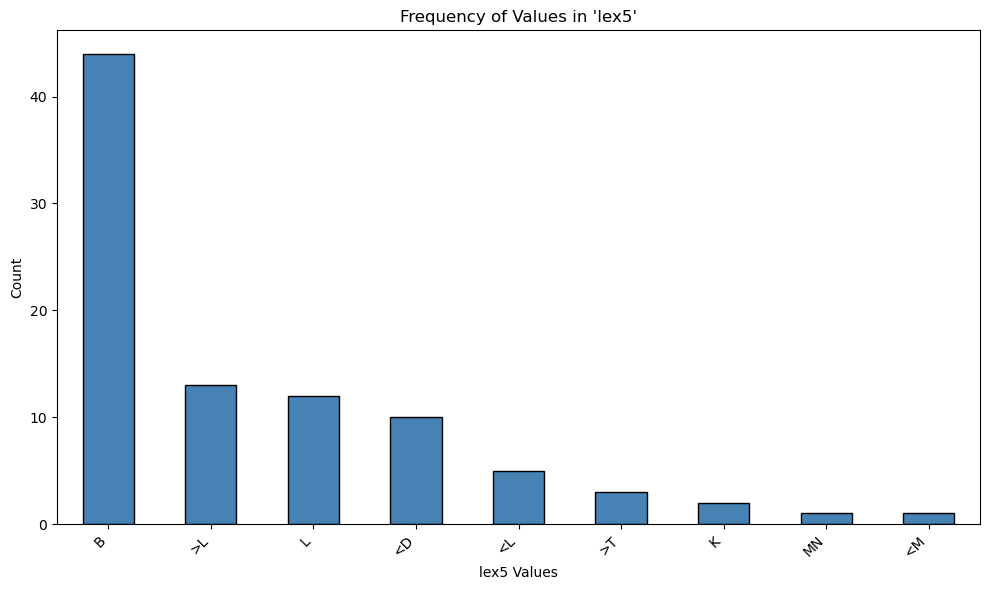

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Count occurrences of each unique string value
counts = ValenceOfCMA['lex5'].value_counts()

# Plot as bar chart
plt.figure(figsize=(10, 6))
counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title("Frequency of Values in 'lex5'")
plt.xlabel("lex5 Values")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


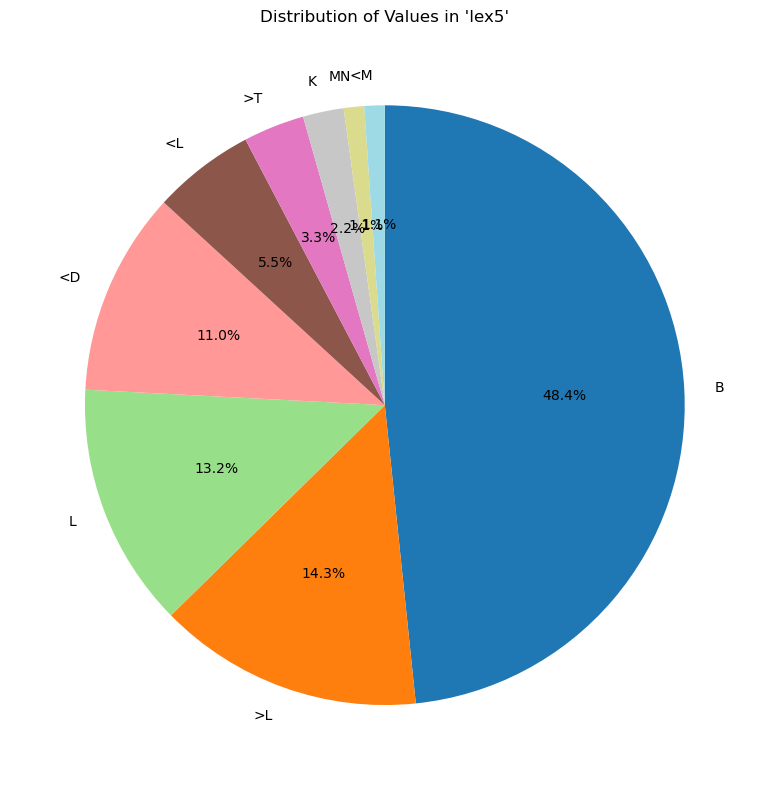

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Count occurrences of each unique string value
counts = ValenceOfCMA['lex5'].value_counts()

# Plot as pie chart
plt.figure(figsize=(8, 8))
counts.plot(
    kind='pie',
    autopct='%1.1f%%',     # show percentages with 1 decimal
    startangle=90,          # start at top
    counterclock=False,     # clockwise order
    colormap='tab20'        # color palette
)

plt.title("Distribution of Values in 'lex5'")
plt.ylabel("")  # remove y-axis label
plt.tight_layout()
plt.show()


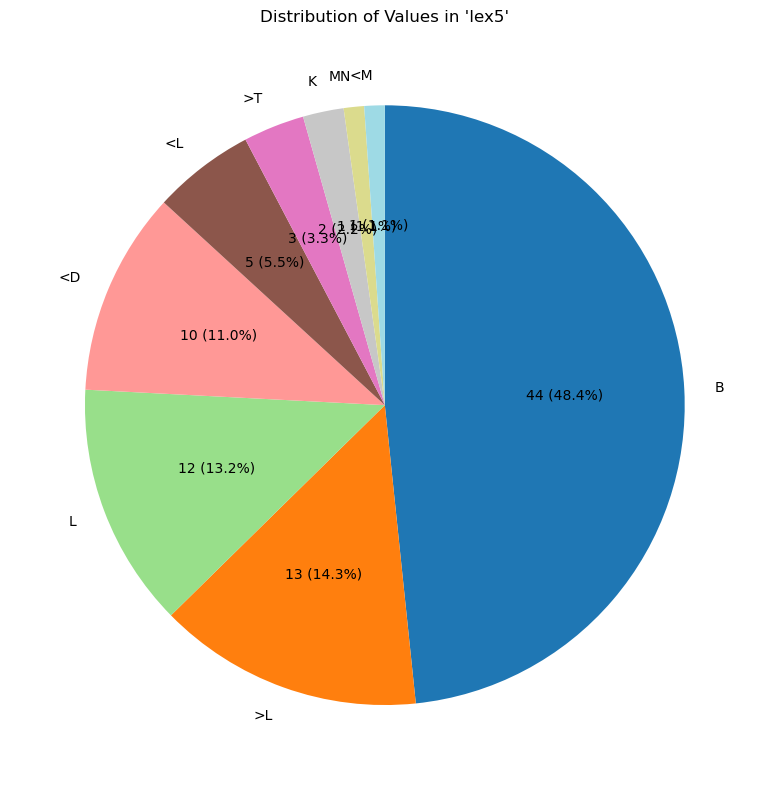

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Count occurrences
counts = ValenceOfCMA['lex5'].value_counts()
total = counts.sum()

# Custom label function: show count + percentage
def make_autopct(values):
    def my_autopct(pct):
        count = int(round(pct * total / 100.0))
        return f'{count} ({pct:.1f}%)'
    return my_autopct

# Plot pie chart
plt.figure(figsize=(8, 8))
counts.plot(
    kind='pie',
    autopct=make_autopct(counts),
    startangle=90,
    counterclock=False,
    colormap='tab20'
)

plt.title("Distribution of Values in 'lex5'")
plt.ylabel("")  # hide y-axis label
plt.tight_layout()
plt.show()


In [13]:
grouped_counts = ValenceOfCMA.groupby('lex5')['lex6'].value_counts()
grouped_counts.head(30)

lex5  lex6   
<D    C<R/       2
      <PR/       1
      H          1
      J<ZR/      1
      JM/        1
      JRWCLM/    1
      L          1
      LB/        1
      YW>R/      1
<L    PH/        2
      DBR/       1
      FPH/       1
      PNH/       1
<M    >DM/       1
>L    H          6
      <YM/       1
      >YL==/     1
      BFR/       1
      CMN/       1
      CNJM/      1
      KL/        1
      MLK/       1
>T    BJT/       1
      H          1
      PR<H/      1
B     KL/        9
      H          6
      NBLH=/     5
      <YM/       2
      KP/        2
Name: count, dtype: int64

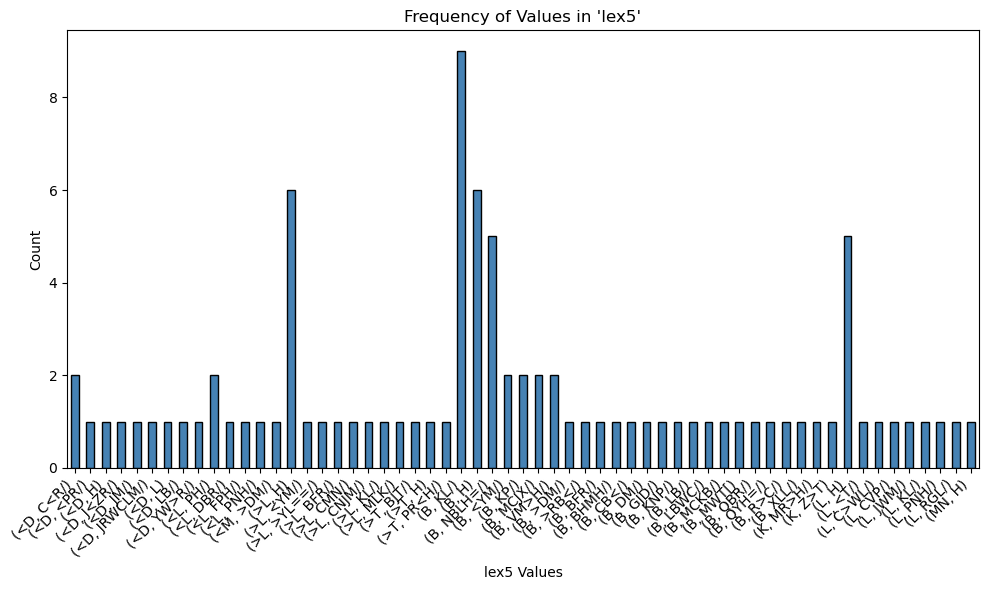

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Count occurrences of each unique string value
counts = ValenceOfCMA.groupby('lex5')['lex6'].value_counts()

# Plot as bar chart
plt.figure(figsize=(10, 6))
counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title("Frequency of Values in 'lex5'")
plt.xlabel("lex5 Values")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


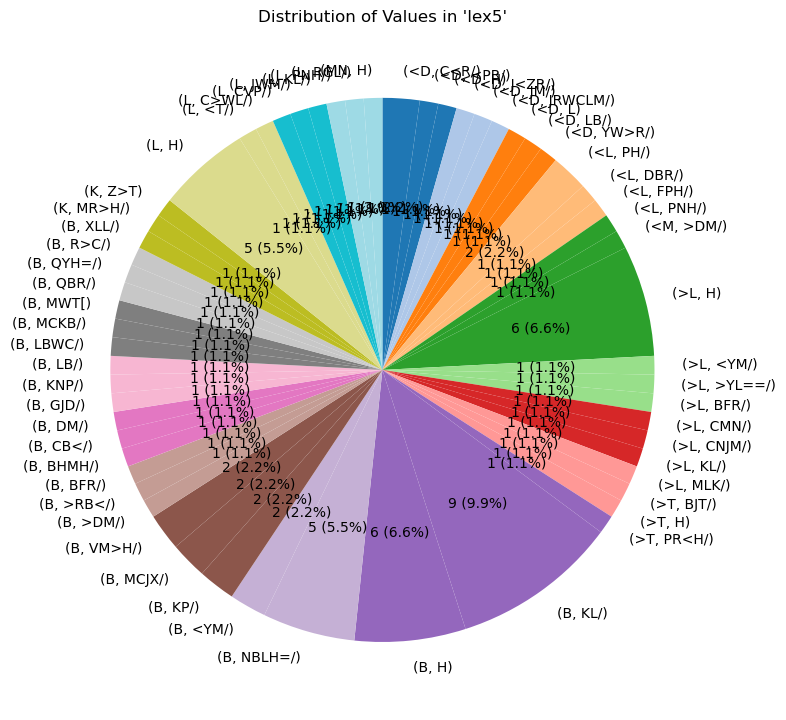

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Count occurrences
counts = ValenceOfCMA.groupby('lex5')['lex6'].value_counts()
total = counts.sum()

# Custom label function: show count + percentage
def make_autopct(values):
    def my_autopct(pct):
        count = int(round(pct * total / 100.0))
        return f'{count} ({pct:.1f}%)'
    return my_autopct

# Plot pie chart
plt.figure(figsize=(8, 8))
counts.plot(
    kind='pie',
    autopct=make_autopct(counts),
    startangle=90,
    counterclock=False,
    colormap='tab20'
)

plt.title("Distribution of Values in 'lex5'")
plt.ylabel("")  # hide y-axis label
plt.tight_layout()
plt.show()


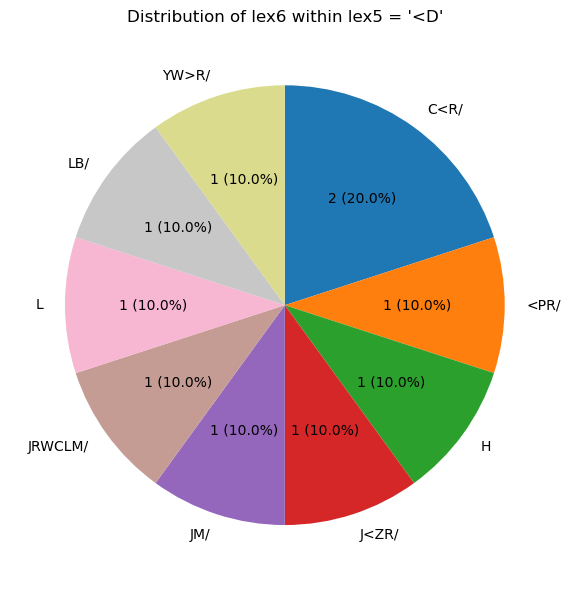

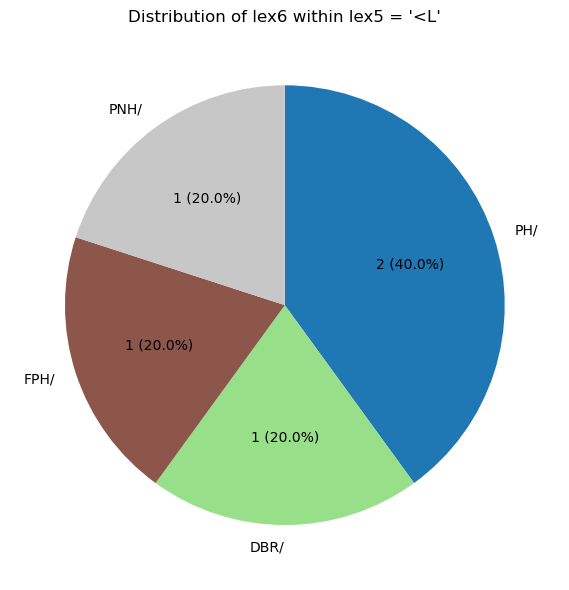

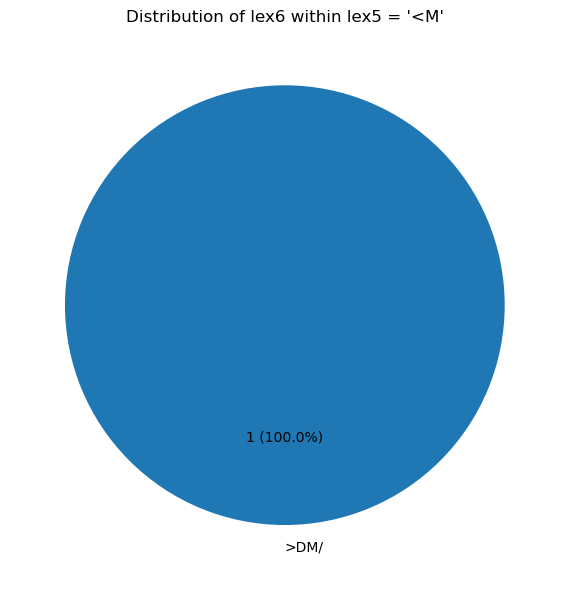

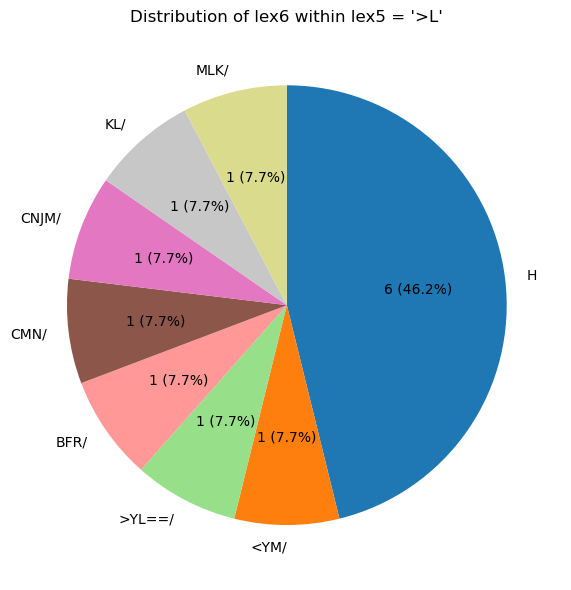

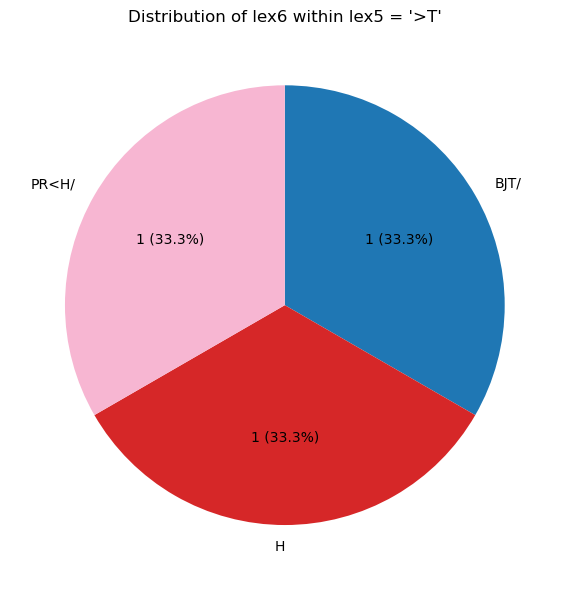

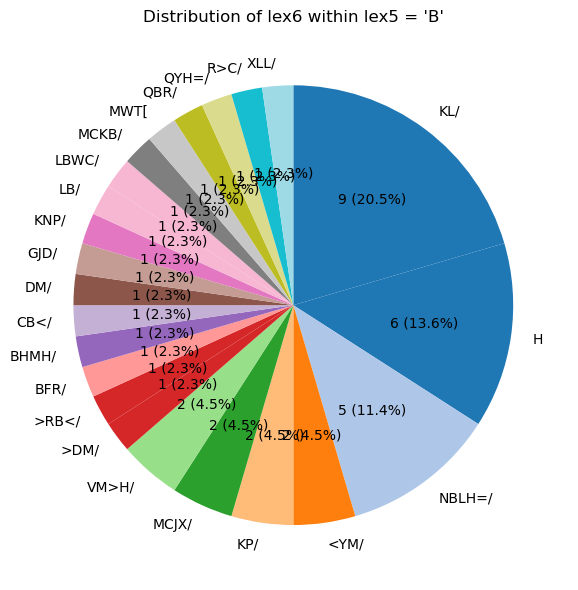

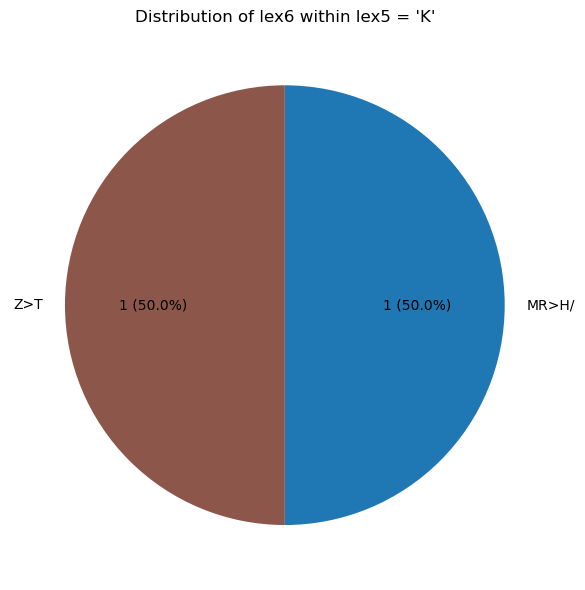

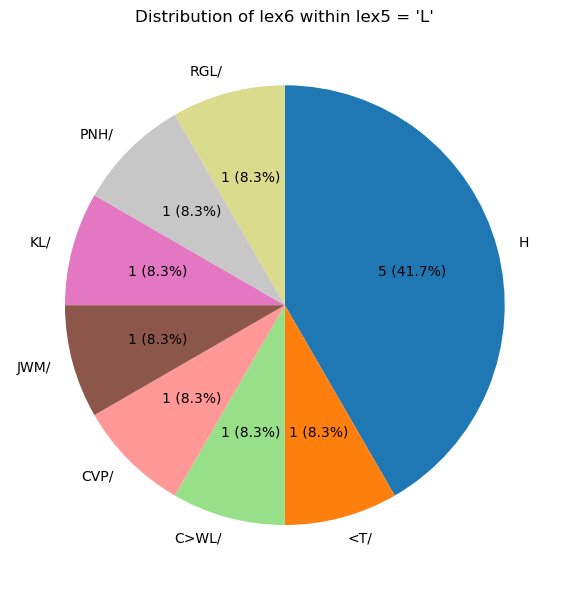

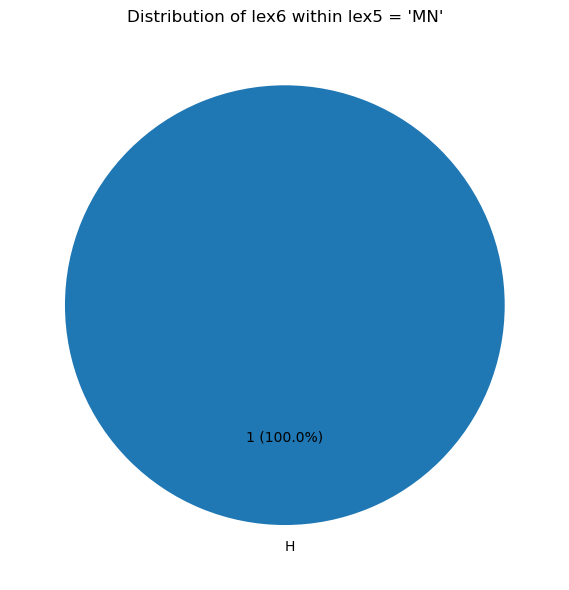

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Group and count lex6 occurrences within each lex5
grouped = ValenceOfCMA.groupby('lex5')['lex6'].value_counts().reset_index(name='count')

# Get unique lex5 values
lex5_groups = grouped['lex5'].unique()

# Create one pie chart per lex5 group
for lex5_value in lex5_groups:
    subset = grouped[grouped['lex5'] == lex5_value]
    
    # Get colors from colormap
    cmap = plt.colormaps['tab20']
    colors = [cmap(i / len(subset)) for i in range(len(subset))]

    
    plt.figure(figsize=(6, 6))
    plt.pie(
        subset['count'],
        labels=subset['lex6'],
        autopct=lambda p: f'{int(round(p * subset["count"].sum() / 100.0))} ({p:.1f}%)',
        startangle=90,
        counterclock=False,
        colors=colors  # Use colors instead of colormap
    )
    
    plt.title(f"Distribution of lex6 within lex5 = '{lex5_value}'")
    plt.tight_layout()
    plt.show()
